---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 14. Радіотехнічні сигнали. Елементи функціонального аналізу</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Радіотехнічні сигнали. Основні поняття та визначення</li>
  <li>Елементи функціонального аналізу</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 14 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Радіотехнічні сигнали. Основні поняття та визначення](#radio-signals-intro)
* [Елементи функціонального аналізу](#functional-analysis)
    * [🔬 Інтерактивно: розклад сигналу за ортогональним базисом](#orthogonal-basis-interactive)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Радіотехнічні сигнали. Основні поняття та визначення <a class="anchor" id="radio-signals-intro"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Класифікувати сигнали за детермінованістю, часовою та амплітудною структурою
> - Розрізняти сигнали зі скінченною енергією та зі скінченною потужністю
> - Використовувати функцію Хевісайда та дельта-функцію для динамічного представлення сигналів
> - Пояснювати просіювальну (фільтрувальну) властивість дельта-функції

</div>

### Класифікація сигналів

**Сигнал** — фізичний процес (найчастіше — зміна напруги чи струму в часі), що несе інформацію. У радіотехніці сигнали класифікують за кількома незалежними ознаками:

| Ознака | Види | Приклад |
|--------|------|---------|
| Детермінованість | **Детерміновані** (наперед точно відомі) / **випадкові** (стохастичні, відомі лише ймовірнісно) | Синусоїда несучої / тепловий шум, мовний сигнал |
| Часова структура | **Періодичні** ($s(t)=s(t+T)$) / **неперіодичні** (одиночні) | Меандр тактового генератора / одиночний радіоімпульс |
| Природа за часом і рівнем | **Аналогові** (неперервні за часом і рівнем) / **дискретні за часом** (відліки) / **цифрові** (дискретні і за часом, і за рівнем) | Мовний сигнал з мікрофона / відліки АЦП / цифровий потік |
| Енергетична ознака | **Сигнали зі скінченною енергією** / **сигнали зі скінченною потужністю** | Одиночний імпульс / періодичний сигнал, шум |

**Енергетичний сигнал** — має скінченну енергію $E=\displaystyle\int_{-\infty}^{\infty}|s(t)|^2dt<\infty$ (і, як наслідок, нульову середню потужність) — типово одиночні, згасаючі в часі сигнали (імпульси, перехідні процеси).

**Потужнісний сигнал** — має скінченну середню потужність $P=\displaystyle\lim_{T\to\infty}\frac1T\int_{-T/2}^{T/2}|s(t)|^2dt<\infty$, але нескінченну енергію — типово періodичні сигнали (несуча, меандр) і стаціонарний шум.

**Типи радіотехнічних сигналів:** гармонічний (несуча частота), модульований (АМ/ЧМ/ФМ — див. розділ «Модуляція» нижче), імпульсний (відео- та радіоімпульси), шумоподібний (завади, псевдовипадкові послідовності), цифровий (кодово-імпульсний, ІКМ).


### Динамічне представлення сигналів. Функція Хевісайда. Дельта-функція

**Функція Хевісайда (одиничний стрибок)** описує миттєве вмикання сигналу в момент $t=t_0$:

$$\mathbf{1}(t-t_0) = \begin{cases} 0, & t<t_0 \\ 1, & t>t_0\end{cases}$$

Довільний сигнал, що існує лише при $t\geq t_0$ (наприклад, реакція кола після комутації), зручно записувати як добуток «природної» формули на $\mathbf{1}(t-t_0)$ — так свідомо «вмикають» математичний вираз лише з потрібного моменту.

**Дельта-функція (функція Дірака)** $\delta(t)$ — узагальнена функція, яка не є звичайною функцією в класичному сенсі, а визначається через свою дію під інтегралом. Її ключові властивості:

$$\delta(t)=0 \;\; (t\neq0), \qquad \int_{-\infty}^{\infty}\delta(t)\,dt = 1$$

**Просіювальна (фільтрувальна) властивість** — найважливіша на практиці:

$$\int_{-\infty}^{\infty} f(t)\,\delta(t-t_0)\,dt = f(t_0)$$

Дельта-функція — це (в узагальненому сенсі) похідна від функції Хевісайда, а функція Хевісайда — інтеграл від дельта-функції:

$$\delta(t) = \frac{d}{dt}\mathbf{1}(t), \qquad \mathbf{1}(t) = \int_{-\infty}^{t}\delta(\tau)\,d\tau$$

**Динамічне представлення довільного сигналу.** Із просіювальної властивості напряму випливає, що будь-який сигнал $s(t)$ можна подати як суперпозицію (неперервну суму, тобто інтеграл) нескінченно вузьких, зсунутих у часі імпульсів:

$$s(t) = \int_{-\infty}^{\infty} s(\tau)\,\delta(t-\tau)\,d\tau$$

Це і є **динамічне представлення сигналу** — воно є основою для означення **імпульсної характеристики** кола $h(t)$ (реакції на $\delta(t)$) та **інтеграла згортки (Дюамеля)**: реакція лінійного кола на довільний вхідний сигнал $s(t)$ дорівнює

$$y(t) = \int_{-\infty}^{\infty} s(\tau)\,h(t-\tau)\,d\tau = s(t)*h(t)$$

тобто розглядається як сума реакцій на нескінченно багато елементарних дельта-імпульсів, з яких «складено» вхідний сигнал.


Проілюструємо, як послідовність прямокутних імпульсів одиничної площі, що стають дедалі вужчими й вищими, наближається до дельта-функції:

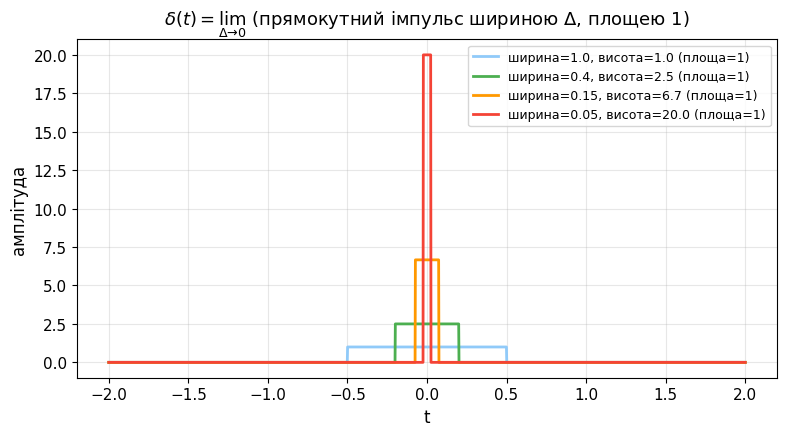

In [2]:
# Наближення дельта-функції прямокутними імпульсами дедалі меншої ширини (і більшої висоти, площа = 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
t_d = np.linspace(-2, 2, 2000)
for width, color in [(1.0, '#90caf9'), (0.4, '#4CAF50'), (0.15, '#FF9800'), (0.05, '#F44336')]:
    height = 1/width
    y = np.where(np.abs(t_d) < width/2, height, 0)
    ax.plot(t_d, y, color=color, lw=2, label=f'ширина={width}, висота={height:.1f} (площа=1)')
ax.set_xlabel('t'); ax.set_ylabel('амплітуда')
ax.set_title(r'$\delta(t) = \lim_{\Delta\to0}$ (прямокутний імпульс шириною $\Delta$, площею 1)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
### ⚡ Практичне застосування: Функція Хевісайда і дельта-функція

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Імпульсна характеристика кола (радіотехніки, фільтрів)** $h(t)$ — реакція системи саме на $\delta(t)$; за нею через інтеграл згортки повністю визначається реакція кола на будь-який вхідний сигнал.
- **Перетворення Лапласа/Фур'є одиничного стрибка й дельта-функції** — базові пари з таблиці перетворень (розділи вище): $\mathbf{1}(t)\to\dfrac1p$, $\delta(t)\to1$ — саме тому дельта-імпульс називають «універсальним тестовим сигналом»: його спектр рівномірний на всіх частотах.
- **Моделювання комутації** — множення сигналу на $\mathbf{1}(t-t_0)$ математично точно відповідає ідеальному ключу, що замикається в момент $t_0$ (див. розділ «Перехідні процеси» вище).

</div>

---
### ✅ Питання для самоперевірки: Радіотехнічні сигнали. Функція Хевісайда, дельта-функція

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чим енергетичний сигнал відрізняється від потужнісного?</summary>

> **Відповідь:** Енергетичний сигнал має скінченну енергію $E=\int|s(t)|^2dt<\infty$ і нульову середню потужність — типово одиночні (згасаючі) сигнали. Потужнісний сигнал має скінченну середню потужність, але нескінченну енергію — типово періодичні сигнали й стаціонарний шум.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> У чому полягає просіювальна властивість дельта-функції?</summary>

> **Відповідь:** $\int f(t)\delta(t-t_0)dt=f(t_0)$ — інтегрування добутку довільної функції на зсунуту дельта-функцію «вибирає» (просіює) значення цієї функції рівно в точці зсуву $t_0$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як пов'язані функція Хевісайда і дельта-функція?</summary>

> **Відповідь:** Дельта-функція — узагальнена похідна функції Хевісайда: $\delta(t)=\dfrac{d}{dt}\mathbf{1}(t)$; і навпаки, функція Хевісайда — інтеграл дельта-функції від $-\infty$ до $t$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Навіщо потрібне динамічне (інтегральне) представлення сигналу через дельта-функції?</summary>

> **Відповідь:** Воно дозволяє звести реакцію лінійного кола на довільний сигнал до суми (інтеграла) реакцій на елементарні зсунуті імпульси — це і є інтеграл згортки (Дюамеля) через імпульсну характеристику кола $h(t)$, один із фундаментальних інструментів аналізу лінійних систем.

</details>

---
### 📝 Задачі для самостійного розв'язання: Радіотехнічні сигнали


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Обчисліть $\displaystyle\int_{-\infty}^{\infty}\delta(t-2)\cos(\pi t)\,dt$ та $\displaystyle\int_{-\infty}^{\infty}\delta(t+1)\,e^{-t^2}\,dt$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> За фільтрувальною властивістю дельта-функції: $\cos(2\pi) = 1$ та $e^{-1} \approx 0{,}368$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Запишіть через функцію Хевісайда прямокутний імпульс амплітудою 5 В, що триває від $t = 1$ мс до $t = 3$ мс, і знайдіть його похідну.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $s(t) = 5[\sigma(t - 1\text{ мс}) - \sigma(t - 3\text{ мс})]$; $s'(t) = 5\delta(t - 1\text{ мс}) - 5\delta(t - 3\text{ мс})$.

</details>

---

## Елементи функціонального аналізу <a class="anchor" id="functional-analysis"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати, чому сигнали можна розглядати як вектори лінійного простору
> - Обчислювати енергію, норму та скалярний добуток сигналів
> - Перевіряти ортогональність двох сигналів
> - Пояснювати, чому ряд Фур'є — окремий випадок розкладу сигналу за ортогональним базисом


</div>


Функціональний аналіз відіграє важливу роль у розумінні властивостей лінійних просторів сигналів та їх взаємодії. В цьому тексті ми розглянемо основні елементи функціонального аналізу, такі як лінійний простір, нормований лінійний простір, скалярний добуток, ортогональні сигнали та концепція ортогонального базису.

### Лінійний простір та його властивості

Лінійний простір - це множина $ V $ над полем $ \mathbb{F} $, де визначені операції додавання та множення на скаляр. Він має наступні властивості:
- Комутативність: $ u + v = v + u, \forall u, v \in V $
- Асоціативність: $ (u + v) + w = u + (v + w), \forall u, v, w \in V $
- Існування нейтрального елемента: $ \exists 0 \in V : v + 0 = v, \forall v \in V $
- Існування оберненого елемента: $ \forall v \in V, \exists -v \in V : v + (-v) = 0 $

### Нормований лінійний простір сигналів

Нормований лінійний простір - це лінійний простір $ V $ над полем $ \mathbb{F} $, в якому визначено норму, тобто відображення $ \| \cdot \| : V \to \mathbb{R} $, що задовольняє наступні аксіоми норми:
- Невід'ємність: $ \|v\| \geq 0, \forall v \in V $ та $ \|v\| = 0 $ тільки якщо $ v = 0 $
- Однорідність: $ \|\alpha v\| = |\alpha| \|v\|, \forall v \in V, \alpha \in \mathbb{F} $
- Нерівність трикутника: $ \|u + v\| \leq \|u\| + \|v\|, \forall u, v \in V $

### Енергія та норма сигналу

Енергія сигналу $ x(t) $ визначається як

$$ E = \int_{-\infty}^{\infty} |x(t)|^2 dt $$

де $ |x(t)|^2 $ - це квадрат модуля сигналу. 

Норма сигналу в нормованому лінійному просторі визначається як

$$ \|x\| = \sqrt{E} $$

### Концепція метрики

Метрика вводиться в нормованому просторі для вимірювання відстані між двома елементами. 

Вона задовольняє такі властивості, як неузгодженість, симетричність та нерівність трикутника.

### Скалярний добуток сигналів та його властивості

Скалярний добуток в нормованому просторі сигналів визначається як
$ \langle x, y \rangle = \int_{-\infty}^{\infty} x(t)y(t) dt $
де $ x(t) $ та $ y(t) $ - це сигнали. Скалярний добуток має наступні властивості:

- Лінійність: $ \langle \alpha x_1 + \beta x_2, y \rangle = \alpha \langle x_1, y \rangle + \beta \langle x_2, y \rangle $

- Симетричність: $ \langle x, y \rangle = \overline{\langle y, x \rangle} $, де $ \overline{\langle y, x \rangle} $ - комплексно спряжений до $ \langle y, x \rangle $

### Ортогональні сигнали

Два сигнали $ x(t) $ та $ y(t) $ в нормованому просторі називаються ортогональними, якщо їх скалярний добуток дорівнює нулю, тобто
$ \langle x, y \rangle = 0 $

### Концепція ортогонального базису

Ортогональний базис - це система векторів, в якій кожні два різних вектори є ортогональними, а також кожен вектор є ненульовим. Ортогональні базиси знаходять широке застосування у сигнальній обробці та аналізі сигналів.

### Приклади ортогональних базисів

Одним з найпоширеніших прикладів ортогонального базису є система тригонометричних функцій, таких як синуси та косинуси, що використовуються в ряді Фур'є для представлення складних сигналів. Іншим прикладом є система власних функцій оператора, таких як власні функції диференціального оператора.

Цей огляд надає загальне уявлення про елементи функціонального аналізу, які є важливими для розуміння властивостей сигналів та їх обробки.


---
### 🔬 Інтерактивно: розклад сигналу за ортогональним базисом <a class="anchor" id="orthogonal-basis-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перевіримо чисельно дві ключові властивості. **Ліворуч** — матриця Грама $\langle u_m, u_n\rangle$ тригонометричного базису на періоді $T$: вона діагональна, тобто функції попарно ортогональні. **Праворуч** — наближення пилкоподібного сигналу проекціями на перші $N$ базисних функцій; норма похибки $\|s - s_N\|$ монотонно зменшується зі зростанням $N$.

</div>

In [3]:
# Інтерактивно: ортогональність тригонометричного базису та наближення сигналу
def orthogonal_basis_demo(N=5):
    T = 1.0
    t = np.linspace(0, T, 4001)
    def basis(k):                  # 1, cos, sin, cos2, sin2, ...
        if k == 0:
            return np.ones_like(t)
        n = (k + 1)//2
        return np.cos(2*np.pi*n*t/T) if k % 2 else np.sin(2*np.pi*n*t/T)
    dot = lambda x, y: np.trapezoid(x*y, t)
    s = t/T - 0.5                  # пилкоподібний сигнал

    K = 9
    G = np.array([[dot(basis(m), basis(n)) for n in range(K)] for m in range(K)])
    s_N = np.zeros_like(t)
    errs = []
    for k in range(2*N + 1):
        u = basis(k)
        s_N = s_N + dot(s, u)/dot(u, u)*u      # C_k = <s,u_k>/||u_k||^2
        errs.append(np.sqrt(dot(s - s_N, s - s_N)))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    im = ax1.imshow(G, cmap='Blues'); fig.colorbar(im, ax=ax1, shrink=0.8)
    names = ['1', 'cos', 'sin', 'cos2', 'sin2', 'cos3', 'sin3', 'cos4', 'sin4']
    ax1.set_xticks(range(K)); ax1.set_xticklabels(names, rotation=60)
    ax1.set_yticks(range(K)); ax1.set_yticklabels(names); ax1.grid(False)
    ax1.set_title('Матриця Грама $\\langle u_m, u_n \\rangle$')
    ax2.plot(t, s, 'k', lw=1.5, label='$s(t)$')
    ax2.plot(t, s_N, 'r', label=f'$s_N(t)$, N = {N}')
    ax2.set_xlabel('t, c'); ax2.legend(); ax2.set_title('Наближення сигналу')
    ax3.semilogy(range(len(errs)), errs, 'o-')
    ax3.set_xlabel('кількість базисних функцій'); ax3.set_title('Норма похибки $\\|s - s_N\\|$')
    plt.tight_layout(); plt.show()

interact(orthogonal_basis_demo, N=widgets.IntSlider(value=5, min=0, max=30, description='N'));

interactive(children=(IntSlider(value=5, description='N', max=30), Output()), _dom_classes=('widget-interact',…

### ✅ Питання для самоперевірки: Функціональний аналіз

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому сигнали можна розглядати як вектори лінійного простору, а не лише як функції часу?</summary>

> **Відповідь:** Множина сигналів задовольняє аксіомам лінійного простору (замкненість щодо додавання й множення на скаляр, існування нульового елемента тощо), тому до неї застосовні геометричні поняття — норма, кут (ортогональність), проєкція — так само, як до звичайних векторів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що означає ортогональність двох сигналів фізично?</summary>

> **Відповідь:** $\langle x,y\rangle=0$ означає, що енергія суми сигналів дорівнює сумі їхніх енергій — «теорема Піфагора» для сигналів: $\|x+y\|^2 = \|x\|^2 + \|y\|^2$. Сигнали не «інтерферують» енергетично.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому саме тригонометричні функції обираються базисом для ряду Фур'є?</summary>

> **Відповідь:** Вони утворюють ортогональний базис на інтервалі періоду $T$, зручні аналітично (похідна й інтеграл синуса/косинуса — знову синус/косинус) і є власними функціями лінійних кіл: реакція лінійного кола на синусоїду залишається синусоїдою тієї ж частоти, що значно спрощує аналіз.

</details>


---
### 📝 Задачі для самостійного розв'язання: Функціональний аналіз


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Знайдіть енергію та норму прямокутного імпульсу амплітудою $A = 2$ В і тривалістю $\tau = 3$ мс.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $E = A^2\tau = 4\cdot3\cdot10^{-3} = 0{,}012$ В²·с; $\|s\| = \sqrt E \approx 0{,}110$ В·с$^{1/2}$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** На інтервалі $[0, 1]$ задано сигнали $u(t) = 1$ і $v(t) = t$. Знайдіть скалярний добуток, «кут» між ними та відстань між сигналами.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\langle u,v\rangle = \int_0^1 t\,dt = 1/2$; $\|u\| = 1$, $\|v\| = 1/\sqrt3$; $\cos\theta = \dfrac{1/2}{1/\sqrt3} = \dfrac{\sqrt3}{2}$, $\theta = 30°$. $d(u,v) = \sqrt{\int_0^1(1-t)^2dt} = 1/\sqrt3 \approx 0{,}577$.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 13. Довга лінія](Тема_13_Довга_лінія.ipynb) &nbsp;|&nbsp; [Тема 15. Ряди та перетворення Фур'є](Тема_15_Ряди_та_перетворення_Фурє.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
